In [7]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs)
csv_path = Path("function_6_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_6/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_6/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2', 'x3', 'x4', 'x5']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()


#Checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

#checking DataFrame
df.head()


Inputs Shape: (31, 5)
Outputs Shape: (31,)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237


In [9]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], x_new[2], x_new[3], x_new[4], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df

#Adding new values to my CSV df
#x_new = [0.412000, 0.346667, 0.542667, 0.738667, 0.150667]
#y_new = -0.22184227121034708

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2', 'x3', 'x4', 'x5' ]].to_numpy()
y = df['y'].to_numpy()

#df = append_bo_result(x_new, y_new)

df.tail()

,x1,x2,x3,x4,x5,y
28,0.432000,0.366667,0.562667,0.758667,0.170667,-0.150611
29,0.487991,0.374112,0.528222,0.656847,0.213014,-0.451795
30,0.442000,0.376667,0.572667,0.768667,0.180667,-0.169881
31,0.422000,0.356667,0.552667,0.748667,0.160667,-0.143413
32,0.412000,0.346667,0.542667,0.738667,0.150667,-0.221842


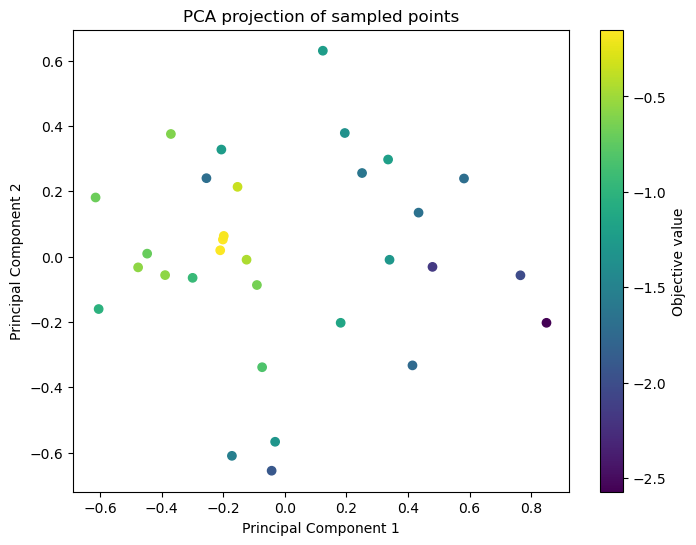

In [78]:
#Create a PCA plot to visulize patterns in the data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.colorbar(scatter, label="Objective value")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of sampled points")
plt.show()

In [87]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

#hyperparamters for GP surrogate model and acqusition function 
rbf_lengthscale = 0.5
noise_assumption = 0.1
xi = 0.00

# Setting number of random candidate points
n_candidates = 5000

# Sample uniformly from [0, 1]^5
X_candidates = np.random.rand(n_candidates, 5)

#Grid based candidate sampling used at the start of the optimisation process 
#g = np.linspace(0.01, 0.99, 16)
#x1g, x2g, x3g, x4g, x5g = np.meshgrid(g, g, g, g, g, indexing='ij')
#X_grid = np.column_stack([x1g.ravel(), x2g.ravel(), x3g.ravel(), x4g.ravel(), x5g.ravel()])
#print(X_grid.shape)

In [89]:
#Fit the GP to current data 

kernel = (C(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.05, 2))
    + WhiteKernel(noise_level=0.1 , noise_level_bounds=(1e-10, 0.5)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=20, random_state=0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5]) + WhiteKernel(noise_level=0.1),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=0)

In [92]:
#Setting up and running acqusition function

from scipy.stats import norm
import numpy as np

#Expected Improvement 

#Write the function
def expected_improvement(mu, sigma, y_best, xi=0):
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

#Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute EI and select next point
ei = expected_improvement(mu, std, y_best, xi=xi)  
ix = int(np.argmax(ei))
x_next = X_candidates[ix]
print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f},{x_next[2]:.6f},{x_next[3]:.6f},{x_next[4]:.6f} ) ")

x_next = (0.337057, 0.070293,0.065228,0.978915,0.202806 ) 


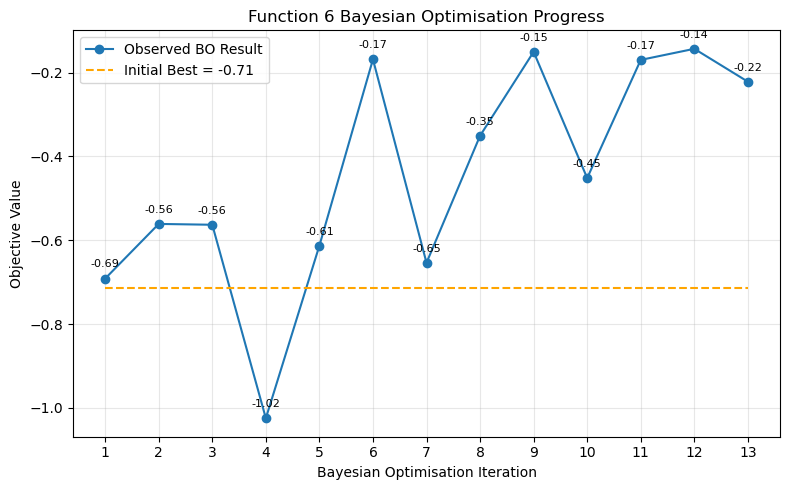

In [15]:
# Plot a graph to track function_6 Bayesian Optimisation progress 
#Intial y_best existing in origional dataset 

INITIAL_BEST_Y = -0.714265  

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 6 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_6_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()